In [1]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['PINECONE_API_KEY'] = os.getenv('PINECONE_API_KEY')
os.environ['COHERE_API_KEY'] = os.getenv('COHERE_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

### 도구 정의

In [2]:
# Tavily Search 도구 생성 및 검색
from langchain_tavily import TavilySearch

tavilly_tool = TavilySearch(max_results=3)
tavilly_tool.invoke("랭그래프의ㅣ 노드와 엣지가 뭐야?")

{'query': '랭그래프의ㅣ 노드와 엣지가 뭐야?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://databoom.tistory.com/entry/LangGraph-%EB%85%B8%EB%93%9Cnode%EC%99%80-%EC%97%A3%EC%A7%80edge',
   'title': '[LangGraph] 노드(node)와 엣지(edge)',
   'content': '## 1. 노드 (Node)\n\n### 1.1.  노드 개념\n\n노드는 데이터를 입력받아 처리한 뒤 결과를 반환하는 실행 단위다.  \nLangGraph에서는 파이썬 함수나 Runnable 객체, 클래스 형태로 정의할 수 있다.\n\n 특징\n  + 하나의 노드는 하나의 역할에 집중하는 것이 좋다.\n  + 입력과 출력은 State를 기반으로 한다.\n  + 노드의 이름은 고유해야 한다.\n\n### 1.2. 노드 만드는 법 기본\n\n#### 1.2.1. 함수로 노드 만들기\n\n입력\n\n state 를 입력으로 받음\n\nreturn 규칙\n\n 반드시 dict 형식으로 반환해야 하며, key는 State에서 정의한 필드와 일치해야 함.\n LangGraph는 이 dict를 기존 state에 \\\\병합(merge)\\\\한다.\n 필요한 필드만 반환해도 되고, 나머지는 이전 state 값이 유지된다.\n\ngraph에 노드 추가하기 [...] ### 2.1. 엣지 개념\n\n엣지는 노드와 노드를 연결하는 경로다. 데이터가 한 노드에서 다음 노드로 흘러가는 길이라고 보면 된다.  \n   \n특징\n\n 엣지는 시작 노드와 도착 노드를 지정해야 한다.\n 조건부 엣지를 설정해 흐름을 분기시킬 수 있다.\n 한 노드에서 여러 노드로 데이터를 보낼 수도 있다.\n\n### 2.2. 엣지 만드는 방법\n\n#### 2.2.1. 일반 edge\n\n```\nbuilde

In [4]:
from typing import TypedDict, Annotated, List     # 타입 힌트 도구
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    messages: Annotated[List, add_messages]  # messages 필드가 add_messages 규칙으로 누적 저장

llm = init_chat_model('gpt-5.6-luna')
tools = [tavilly_tool]
llm_with_tools = llm.bind_tools(tools)

# State의 messages를 입력으로 받아, 응답 메시지를 추가해주는 노드 함수
def chatbot(state: State):
    response = llm.invoke(state['messages'])  # 누적된 메시지 리스트로 LLM 호출
    return {'messages': [response]}  # add_messages 규칙에 의해 기존 messages에 응답이 누적됨

In [ ]:
from langchain_core.messages import ToolMessage
import json

class ToolNode:
    def __init__(self, tools):
        self.tools_by_name = {tool.name for tool in tools}

    def __call__(self, inputs: State):
        """
        도구 호출을 처리하는 메서드입니다.

        Args:
            inputs (dict): 입력 상태 딕셔너리. 'messages' 키에 메시지 리스트가 포함되어야 합니다.

        Returns:
            dict: 도구 실행 결과를 담은 메시지 리스트가 포함된 딕셔너리.
                 형식: {"messages": [ToolMessage, ...]}

        Raises:
            ValueError: 입력에 메시지가 없는 경우 발생합니다.
        """
        if messages := inputs.get("messages"):
            message = messages[-1]

        else:
            raise ValueError("메세지가 없습니다.")

        outputs = []    # ToolMessage 들을 담을 리스트

        # 마지막 메시지(AI Message)에 포함돈 tool_calls를 수행
        for tool_call  in message.tool_calls:
            # tool 이름을 찾아 실행(매개변수는 ai메세지에서 전달한 입력매개변수)
            tool_result = self.tool_by_name[tool_call['name']].invoke(tool_call['args'])
            tool_message = ToolMessage(
                content = json.dump(tool_result),   # 결과를 json으로 파싱
                name = tool_call['name'],
                tool_call_id = tool_call['id']
            )
            outputs.append(tool_message)

        return {'messages': outputs}

In [ ]:
# 도구 호출 여부에 따른 분기 함수(tools_condition)
# -> 다음 분기로 tools로 보낼지 아니면 END로 끝낼지 결정
from pprint import pprint

def tools_condition(state: State):
    pprint(state['messages'])

    if isinstance(state, list):     # state가 list형태일 경우 (MessagesGraph)
        ai_message = state[-1]      # 마지막 메세지는 AIMessage
    elif messages := state.get("messages", []): # state가 dict 형태(stateGraph)인 경우
        ai_message = messages[-1]
    else:
        raise ValueError(f"State의 tool_edge에서 들어온 메세지 확인 불가: {state}")

    # AIMessage에 tool_calls가 있으면 도구 노드로 이동
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return 'tools'

    # tool_calls가 없으면 END 노드로 이동
    return END

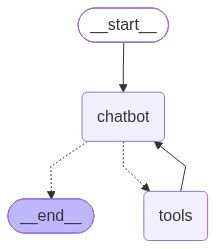

In [10]:
# 직접 구현한 ToolNode와 tools_condition 함수 사용한 워크플로우
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(State)  # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)


workflow.add_edge(START, 'chatbot')  # 시작 노드 -> chatbot 노드

workflow.add_node('chatbot', chatbot)  # chatbot 노드
workflow.add_node('tools', tool_node)  # tools 노드

workflow.add_conditional_edges('chatbot', tools_condition, {'tools': 'tools', END:END})
workflow.add_edge('tools', 'chatbot')

graph = workflow.compile()  # 설계된 워크프로우를 실행 가능한 그래프로 컴파일

graph  # 그래프 객체

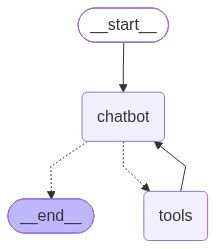

In [11]:
# langgraph.prebuilt 모듈의 ToolNode, tools_condition 함수 사용한 워크플로우
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

workflow = StateGraph(State)  # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)


workflow.add_edge(START, 'chatbot')  # 시작 노드 -> chatbot 노드

workflow.add_node('chatbot', chatbot)  # chatbot 노드
workflow.add_node('tools', tool_node)  # tools 노드

workflow.add_conditional_edges('chatbot', tools_condition, {'tools': 'tools', END:END})
workflow.add_edge('tools', 'chatbot')

graph = workflow.compile()  # 설계된 워크프로우를 실행 가능한 그래프로 컴파일

graph  # 그래프 객체

In [ ]:
user_query = '랭그래프의 구성요소는?'

state = {'messages': [HumanMessage(content=user_query)]}    # HumanMessage 객체 내 메세지 구현 

response = graph.invoke(state)      # 그래프 실행 (START -> CHATBOT -> (tool 루프)or END)

pprint(response)
print('='*100)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='랭그래프의 구성요소는?', additional_kwargs={}, response_metadata={}, id='6fc900f7-9f58-4850-bfb9-6a045d081966'),
              AIMessage(content='랭그래프(LangGraph)는 **상태(state)를 중심으로 여러 작업을 그래프로 연결해 실행하는 프레임워크**입니다. 주요 구성요소는 다음과 같습니다.\n\n1. **State(상태)**\n   - 그래프 실행 중 노드들이 공유하는 데이터입니다.\n   - 예: 대화 메시지, 사용자 정보, 중간 결과, 작업 상태\n   - TypedDict, dataclass, Pydantic 모델 등으로 정의할 수 있습니다.\n\n2. **Node(노드)**\n   - 실제 작업을 수행하는 함수 또는 실행 단위입니다.\n   - 예: LLM 호출, 도구 실행, 데이터베이스 조회, 문서 검색, 검증\n\n3. **Edge(엣지)**\n   - 노드 간 실행 흐름을 연결합니다.\n   - 일반 엣지: 항상 다음 노드로 이동\n   - 조건부 엣지: 상태에 따라 다음 노드를 동적으로 선택\n\n4. **Start / End**\n   - `START`: 그래프 실행 시작점\n   - `END`: 그래프 실행 종료점\n\n5. **Graph(StateGraph)**\n   - 상태 스키마와 노드, 엣지를 조합해 전체 워크플로를 구성하는 객체입니다.\n   - 구성 후 `compile()`하여 실행 가능한 그래프로 만듭니다.\n\n6. **Reducer(상태 갱신 규칙)**\n   - 여러 노드의 결과를 기존 상태에 어떻게 합칠지 정의합니다.\n   - 예를 들어 메시지 목록에 새 메시지를 추가하거나 값을 덮어쓸 수 있습니다.\n\n7. **Checkpoint / Persistence**\n   - 실행 중인 그래프의 상태를 저장하고 복원합니다.\n   - 대화 기억, 중단 후

In [15]:
user_query = '2026년 최근 우리나라의 산불 횟수는?'

state = {'messages': [HumanMessage(content=user_query)]}    # HumanMessage 객체 내 메세지 구현 

response = graph.invoke(state)      # 그래프 실행 (START -> CHATBOT -> (tool 루프)or END)

pprint(response)
print('='*100)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='2026년 최근 우리나라의 산불 횟수는?', additional_kwargs={}, response_metadata={}, id='eb668421-f296-4859-8487-0599760978f5'),
              AIMessage(content='2026년 우리나라 산불 발생 건수는 **집계 기준일에 따라 달라집니다.** 산림청의 공식 **산불통계 ‘발생건수’**를 기준으로 확인해야 하며, 신고 건수·산불 발생 건수·피해 면적은 서로 다를 수 있습니다.\n\n현재 저는 실시간 산림청 통계를 조회할 수 있어 **2026년 누계 정확한 숫자를 단정하기 어렵습니다.**  \n최신 수치는 산림청 홈페이지에서 다음 경로로 확인할 수 있습니다.\n\n**산림청 → 산불정보 → 산불통계 → 연도별 산불발생 현황 → 2026년**\n\n원하시면 기준일을 정해 주시면(예: **2026년 9월 3일 현재**) 공식 통계 기준으로 확인해야 할 항목과 읽는 방법을 정리해 드리겠습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 533, 'prompt_tokens': 20, 'total_tokens': 553, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 329, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai',